1. Imports

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("Libraries loaded successfully.")

Libraries loaded successfully.


2. Load data

In [19]:
df_wb = pd.read_csv("nb01_wb_prices_clean.csv", parse_dates=["month_date"])
df_fx = pd.read_csv("nb02_fx_monthly_clean.csv", parse_dates=["month_date"])

print("World Bank shape:", df_wb.shape)
print("FX shape:", df_fx.shape)
print("World Bank columns:", df_wb.columns.to_list())
print("FX columns:", df_fx.columns.to_list())

World Bank shape: (137, 5)
FX shape: (138, 7)
World Bank columns: ['month_date', 'cpo_price', 'soyoil_price', 'sunflower_price', 'rapeseed_price']
FX columns: ['month_date', 'usd_inr', 'usd_cny', 'usd_idr', 'usd_myr', 'soybean_futures_usd', 'brent_crude_usd']


3. Standardize dates and join

In [20]:
df_wb["month_date"] = df_wb["month_date"].dt.to_period("M").dt.to_timestamp()
df_fx["month_date"] = df_fx["month_date"].dt.to_period("M").dt.to_timestamp()

df = df_wb.merge(df_fx, on="month_date", how="inner")

print("Shape after join:", df.shape)
print("Date range:", df["month_date"].min(), "to", df["month_date"].max())
print("\nNull values:\n", df.isnull().sum())

Shape after join: (137, 11)
Date range: 2015-01-01 00:00:00 to 2026-05-01 00:00:00

Null values:
 month_date             0
cpo_price              0
soyoil_price           0
sunflower_price        0
rapeseed_price         0
usd_inr                0
usd_cny                0
usd_idr                0
usd_myr                0
soybean_futures_usd    0
brent_crude_usd        0
dtype: int64


4. POGO spread

In [21]:
# convert Brent from USD/barrel to USD/tonne (1 tonne = 7.33 barrels)
df["gasoil_usd_per_tonne"] = df["brent_crude_usd"] * 7.33

# POGO spread - positive means biodiesel is profitable
df["pogo_spread"] = df["cpo_price"] - df["gasoil_usd_per_tonne"]

# label the zones based on spread thresholds (these can be adjusted as needed)
def pogo_zone(spread):
    if spread < 0:      return "PROFITABLE"   # gas oil > CPO, biodiesel makes money, strongest demand
    elif spread < 150:  return "MARGINAL"    # CPO slightly above gas oil, subsidy needed but manageable
    else:               return "COSTLY"       # CPO far above gas oil, heavy subsidy burden, mandate risk

df["pogo_zone"] = df["pogo_spread"].apply(pogo_zone)

print(df[["month_date", "cpo_price", "gasoil_usd_per_tonne", "pogo_spread", "pogo_zone"]].tail(10).to_string())

    month_date  cpo_price  gasoil_usd_per_tonne  pogo_spread pogo_zone
127 2025-08-01    1026.12            499.319620   526.800380    COSTLY
128 2025-09-01    1036.74            491.256575   545.483425    COSTLY
129 2025-10-01    1038.09            476.963098   561.126902    COSTLY
130 2025-11-01     983.40            463.256006   520.143994    COSTLY
131 2025-12-01     980.12            446.030489   534.089511    COSTLY
132 2026-01-01    1004.66            518.157718   486.502282    COSTLY
133 2026-02-01    1039.47            531.278425   508.191575    COSTLY
134 2026-03-01    1108.61            867.505489   241.104511    COSTLY
135 2026-04-01    1146.20            835.693316   310.506684    COSTLY
136 2026-05-01    1139.94            674.726522   465.213478    COSTLY


5. CPO price z-score

In [22]:
window = 36

df["cpo_rolling_mean"] = df["cpo_price"].rolling(window).mean()
df["cpo_rolling_std"]  = df["cpo_price"].rolling(window).std()
df["cpo_zscore"]       = (df["cpo_price"] - df["cpo_rolling_mean"]) / df["cpo_rolling_std"]

def price_cycle(z):
    if pd.isna(z):   return "INSUFFICIENT DATA"
    elif z > 1:      return "EXPENSIVE"
    elif z < -1:     return "CHEAP"
    else:            return "FAIR"

df["price_cycle_position"] = df["cpo_zscore"].apply(price_cycle)

print(df[["month_date", "cpo_price", "cpo_zscore",
          "price_cycle_position"]].tail(12).to_string())

    month_date  cpo_price  cpo_zscore price_cycle_position
125 2025-06-01     935.39   -0.095258                 FAIR
126 2025-07-01     976.38    0.355740                 FAIR
127 2025-08-01    1026.12    0.876686                 FAIR
128 2025-09-01    1036.74    0.940086                 FAIR
129 2025-10-01    1038.09    0.904789                 FAIR
130 2025-11-01     983.40    0.331101                 FAIR
131 2025-12-01     980.12    0.285801                 FAIR
132 2026-01-01    1004.66    0.517675                 FAIR
133 2026-02-01    1039.47    0.839162                 FAIR
134 2026-03-01    1108.61    1.453187            EXPENSIVE
135 2026-04-01    1146.20    1.709664            EXPENSIVE
136 2026-05-01    1139.94    1.542137            EXPENSIVE


6. MYR vs IDR competitiveness index

In [23]:
# Index both to 100 at January 2015 for fair comparison
base_date = "2015-01-01"
base_myr = df.loc[df["month_date"] == base_date, "usd_myr"].values[0]
base_idr = df.loc[df["month_date"] == base_date, "usd_idr"].values[0]

df["myr_indexed"] = (df["usd_myr"] / base_myr) * 100
df["idr_indexed"] = (df["usd_idr"] / base_idr) * 100

print(f"Base MYR (Jan 2015): {base_myr:.4f}")
print(f"Base IDR (Jan 2015): {base_idr:.2f}")
print()
print(df[["month_date", "usd_myr", "myr_indexed",
          "usd_idr", "idr_indexed"]].head(6).to_string())

Base MYR (Jan 2015): 3.5768
Base IDR (Jan 2015): 12527.77

  month_date   usd_myr  myr_indexed       usd_idr  idr_indexed
0 2015-01-01  3.576841   100.000000  12527.772714   100.000000
1 2015-02-01  3.595490   100.521387  12735.150168   101.655342
2 2015-03-01  3.679295   102.864388  13034.045433   104.041203
3 2015-04-01  3.623968   101.317570  12938.136350   103.275631
4 2015-05-01  3.598381   100.602210  13082.761681   104.430069
5 2015-06-01  3.730368   104.292260  13282.500038   106.024433


7. Chart 1: POGO spread with zones

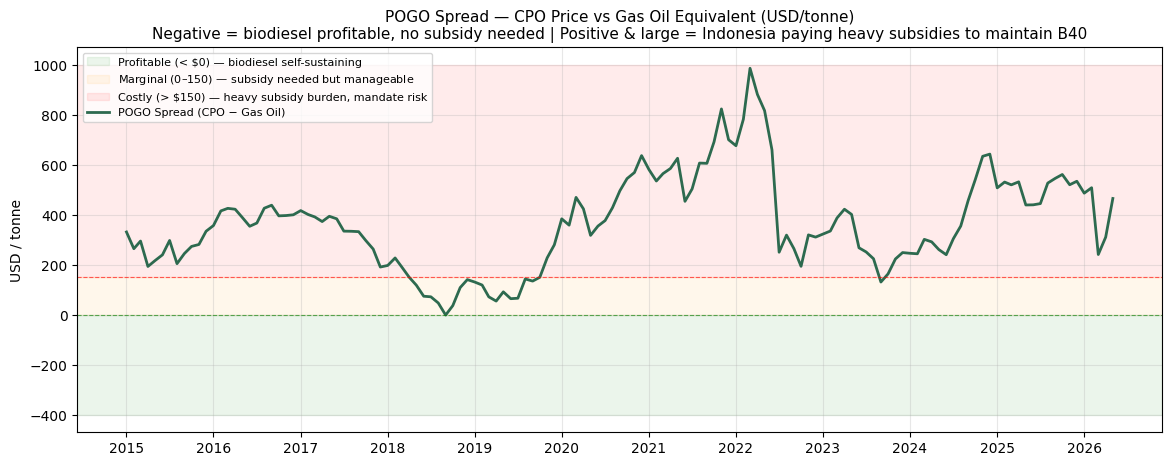

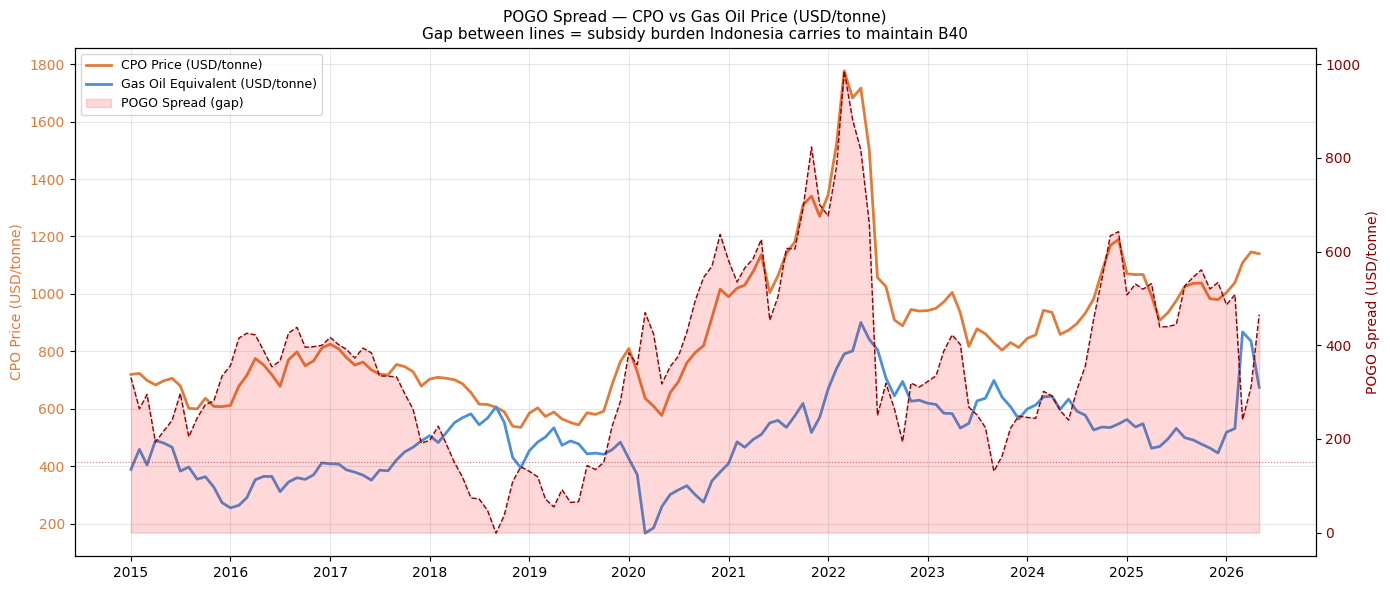

<Figure size 640x480 with 0 Axes>

Chart 1 saved


In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

# Shade the three zones
ax.axhspan(-400, 0,   alpha=0.08, color="green",  label="Profitable (< $0) — biodiesel self-sustaining")
ax.axhspan(0,    150, alpha=0.08, color="orange", label="Marginal ($0–$150) — subsidy needed but manageable")
ax.axhspan(150,  1000, alpha=0.08, color="red",    label="Costly (> $150) — heavy subsidy burden, mandate risk")

# POGO spread line
ax.plot(df["month_date"], df["pogo_spread"],
        color="#2d6a4f", linewidth=2, label="POGO Spread (CPO − Gas Oil)")

# Reference lines
ax.axhline(y=0,   color="green",  linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(y=150, color="red",    linestyle="--", linewidth=0.8, alpha=0.6)

ax.set_title("POGO Spread — CPO Price vs Gas Oil Equivalent (USD/tonne)\n"
             "Negative = biodiesel profitable, no subsidy needed | "
             "Positive & large = Indonesia paying heavy subsidies to maintain B40",
             fontsize=11)
ax.set_ylabel("USD / tonne")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
fig, ax1 = plt.subplots(figsize=(14, 6))

# CPO price on left axis
ax1.plot(df["month_date"], df["cpo_price"],
         color="#e07b39", linewidth=2, label="CPO Price (USD/tonne)")
ax1.set_ylabel("CPO Price (USD/tonne)", color="#e07b39")
ax1.tick_params(axis="y", labelcolor="#e07b39")

# Gas oil on same left axis
ax1.plot(df["month_date"], df["gasoil_usd_per_tonne"],
         color="#4a90d9", linewidth=2, label="Gas Oil Equivalent (USD/tonne)")

# POGO spread as a filled area on right axis
ax2 = ax1.twinx()
ax2.fill_between(df["month_date"], df["pogo_spread"],
                 alpha=0.15, color="red", label="POGO Spread (gap)")
ax2.plot(df["month_date"], df["pogo_spread"],
         color="darkred", linewidth=1, linestyle="--")
ax2.set_ylabel("POGO Spread (USD/tonne)", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")
ax2.axhline(y=150, color="darkred", linestyle=":", linewidth=0.8, alpha=0.5)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

ax1.set_title("POGO Spread — CPO vs Gas Oil Price (USD/tonne)\n"
              "Gap between lines = subsidy burden Indonesia carries to maintain B40",
              fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig("nb03_chart1_pogo_spread.png", dpi=150, bbox_inches="tight")
plt.show()
plt.tight_layout()
plt.savefig("nb03_chart1_pogo_spread.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 1 saved")

8. chart 2: CPO price z-score cycle position

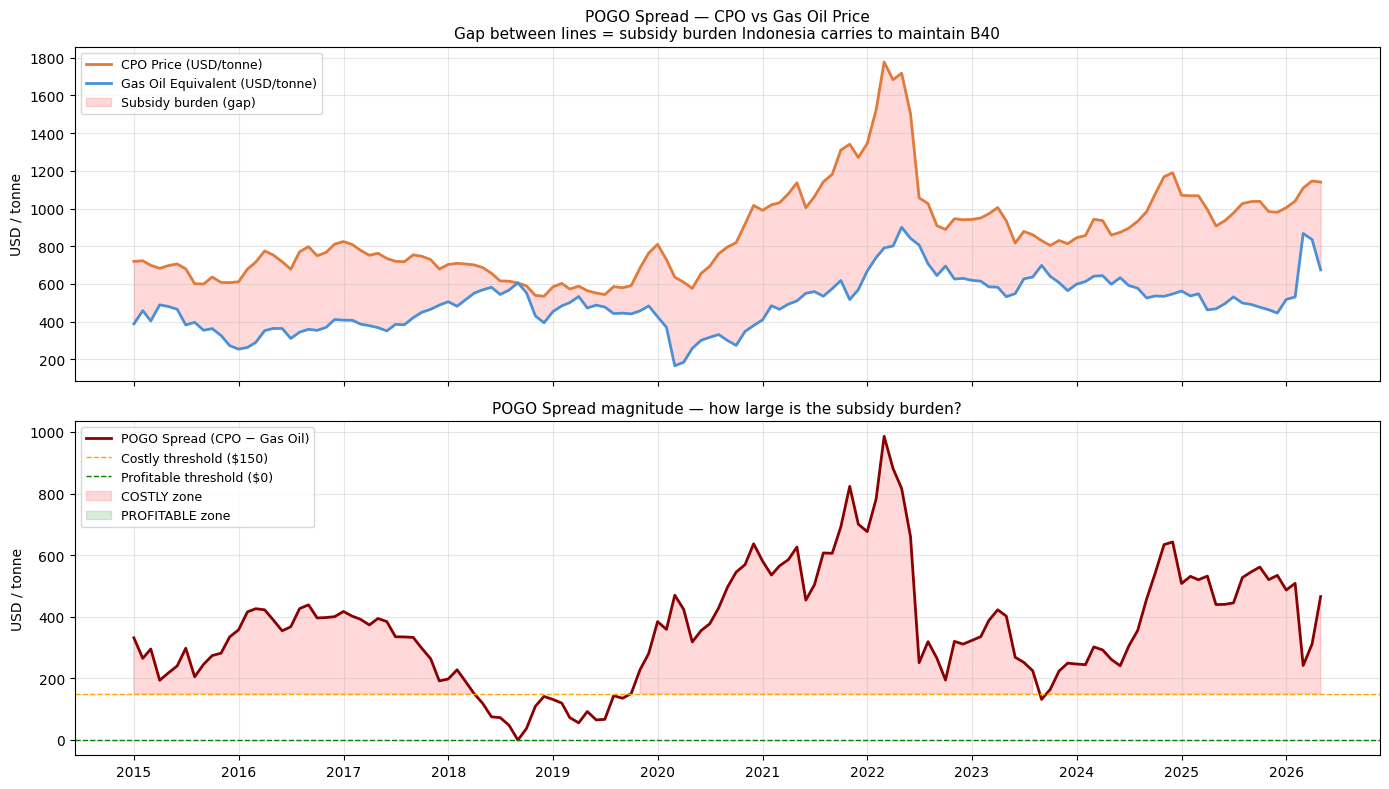

In [25]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# --- Top chart: CPO and Gas Oil prices on same axis ---
ax1.plot(df["month_date"], df["cpo_price"],
         color="#e07b39", linewidth=2, label="CPO Price (USD/tonne)")
ax1.plot(df["month_date"], df["gasoil_usd_per_tonne"],
         color="#4a90d9", linewidth=2, label="Gas Oil Equivalent (USD/tonne)")

# Shade the gap between the two lines
ax1.fill_between(df["month_date"], df["cpo_price"], df["gasoil_usd_per_tonne"],
                 alpha=0.15, color="red", label="Subsidy burden (gap)")

ax1.set_ylabel("USD / tonne")
ax1.set_title("POGO Spread — CPO vs Gas Oil Price\n"
              "Gap between lines = subsidy burden Indonesia carries to maintain B40",
              fontsize=11)
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Bottom chart: POGO spread as a single line ---
ax2.plot(df["month_date"], df["pogo_spread"],
         color="darkred", linewidth=2, label="POGO Spread (CPO − Gas Oil)")
ax2.axhline(y=150, color="orange", linestyle="--",
            linewidth=1, label="Costly threshold ($150)")
ax2.axhline(y=0,   color="green",  linestyle="--",
            linewidth=1, label="Profitable threshold ($0)")
ax2.fill_between(df["month_date"], df["pogo_spread"], 150,
                 where=(df["pogo_spread"] > 150),
                 alpha=0.15, color="red",   label="COSTLY zone")
ax2.fill_between(df["month_date"], df["pogo_spread"], 0,
                 where=(df["pogo_spread"] < 0),
                 alpha=0.15, color="green", label="PROFITABLE zone")

ax2.set_ylabel("USD / tonne")
ax2.set_title("POGO Spread magnitude — how large is the subsidy burden?", fontsize=11)
ax2.legend(loc="upper left", fontsize=9)
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig("nb03_chart1_pogo_spread.png", dpi=150, bbox_inches="tight")
plt.show()

9. Chart 3: MYR vs IDR competitiveness

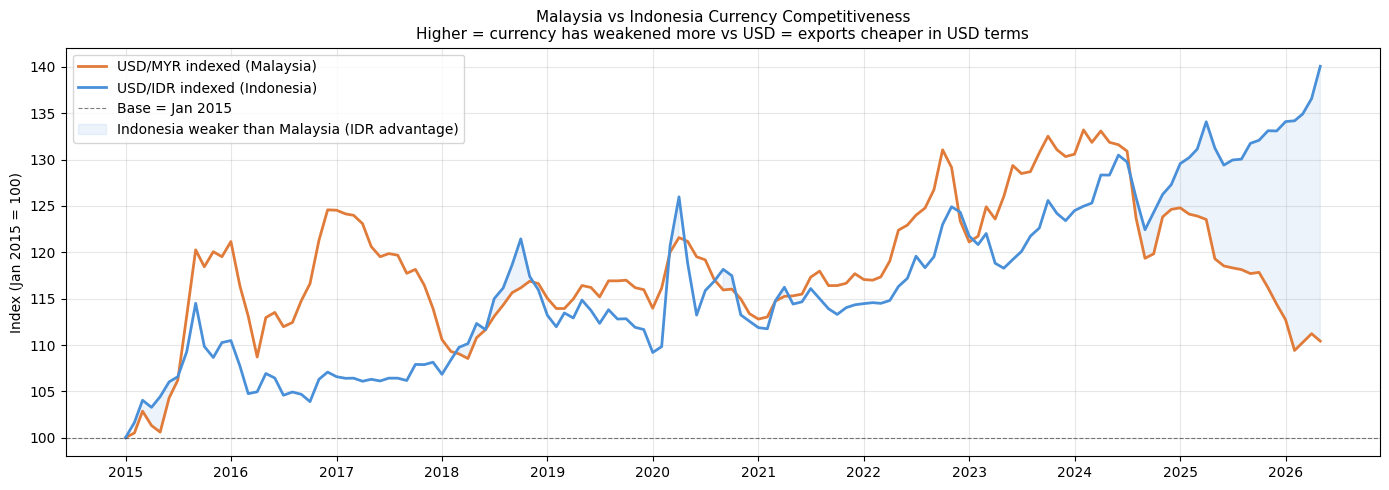

Chart 3 saved


In [26]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["month_date"], df["myr_indexed"],
        color="#e07b39", linewidth=2, label="USD/MYR indexed (Malaysia)")
ax.plot(df["month_date"], df["idr_indexed"],
        color="#4a90d9", linewidth=2, label="USD/IDR indexed (Indonesia)")

ax.axhline(y=100, color="black", linestyle="--", linewidth=0.8,
           alpha=0.5, label="Base = Jan 2015")

# Shade the gap — when IDR line is above MYR line, Indonesia has weakened more
ax.fill_between(df["month_date"], df["myr_indexed"], df["idr_indexed"],
                where=(df["idr_indexed"] > df["myr_indexed"]),
                alpha=0.1, color="#4a90d9",
                label="Indonesia weaker than Malaysia (IDR advantage)")

ax.set_title("Malaysia vs Indonesia Currency Competitiveness\n"
             "Higher = currency has weakened more vs USD = exports cheaper in USD terms",
             fontsize=11)
ax.set_ylabel("Index (Jan 2015 = 100)")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.savefig("nb03_chart3_myr_idr_competitiveness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 3 saved")

10. Save output csv

In [27]:
output_cols = [
    'month_date', 
    'cpo_price', 
    'soyoil_price', 
    'sunflower_price', 
    'rapeseed_price', 
    'usd_inr', 
    'usd_cny', 
    'usd_idr', 
    'usd_myr', 
    'soybean_futures_usd', 
    'brent_crude_usd', 
    'gasoil_usd_per_tonne', 
    'pogo_spread', 
    'pogo_zone', 
    'cpo_rolling_mean', 
    'cpo_rolling_std', 
    'cpo_zscore', 
    'price_cycle_position', 
    'myr_indexed', 
    'idr_indexed'
]
 
df[output_cols].to_csv("nb03_biodiesel_pricecycle.csv", index=False)
print("Saved: nb03_biodiesel_pricecycle.csv")
print(f"Shape: {df[output_cols].shape}")
print(f"Columns: {output_cols}")

Saved: nb03_biodiesel_pricecycle.csv
Shape: (137, 20)
Columns: ['month_date', 'cpo_price', 'soyoil_price', 'sunflower_price', 'rapeseed_price', 'usd_inr', 'usd_cny', 'usd_idr', 'usd_myr', 'soybean_futures_usd', 'brent_crude_usd', 'gasoil_usd_per_tonne', 'pogo_spread', 'pogo_zone', 'cpo_rolling_mean', 'cpo_rolling_std', 'cpo_zscore', 'price_cycle_position', 'myr_indexed', 'idr_indexed']


## Notebook 03 — Findings & Decisions

**Sources:** Notebook 01 (World Bank prices) + Notebook 02 (yfinance FX + futures)
**Join type:** Inner join on month_date
**Shape after join:** 137 rows × 11 columns
**Date range:** 2015-01-01 → 2026-05-01
**Null values:** None

**Columns produced in this notebook:**
- gasoil_usd_per_tonne (brent_crude_usd × 7.3)
- pogo_spread (cpo_price − gasoil_usd_per_tonne)
- pogo_zone (PROFITABLE / MARGINAL / COSTLY)
- cpo_rolling_mean, cpo_rolling_std (36-month rolling)
- cpo_zscore (36-month rolling z-score)
- price_cycle_position (EXPENSIVE / FAIR / CHEAP)
- myr_indexed, idr_indexed (both indexed to 100 at Jan 2015)

---

### Chart 1 — POGO Spread (revised)

**Chart structure:** Two subplots sharing x-axis.
- Top: CPO price vs gas oil price on the same axis, gap shaded red
- Bottom: POGO spread magnitude as a single line with zone thresholds

**Why dual-axis was removed:** Original dual-axis version made the shaded area
appear larger than CPO price because the two y-axes had different scales.
Putting everything on one axis makes the gap visually honest and immediately
readable.

**Key observations from the top chart:**
- CPO (orange) is consistently above gas oil (blue) for the entire 2015–2026
  period — confirming biodiesel has always required subsidies in this dataset
- The gap was narrowest during 2018–2020 when Brent crude was relatively high
  and CPO prices were depressed — the only period where the subsidy burden was
  manageable without heavy fund drawdown
- The gap exploded in 2022 when CPO spiked to ~$1,800/tonne while gas oil stayed
  around $800/tonne — the widest subsidy burden in the dataset (~$1,000/tonne)
  This triggered Indonesia's temporary CPO export ban in April 2022
- Post-2022 the gap narrowed as CPO corrected downward, then widened again in
  2025–2026 as CPO recovered while Brent stayed range-bound

**Key observations from the bottom chart:**
- PROFITABLE zone (below $0): Never reached in this dataset
- MARGINAL zone ($0–$150): Only 2018–2020, the lowest subsidy burden period
- COSTLY zone (above $150): Dominant state across 2015–2026
- Peak spread: ~$1,000/tonne in 2022
- Current spread (May 2026): ~$465/tonne — costly but significantly below 2022 peak

**The actual insight this chart gives SD Guthrie:**
The question is never whether Indonesia will run its biodiesel program — they always
will. The question is whether the BPDPKS levy fund can cover the subsidy burden.
When the spread is rising rapidly toward or beyond the 2022 peak level, watch for
an Indonesia policy response — export restrictions, levy increases, or mandate
pause — any of which directly affects global CPO supply and Malaysia's export volumes.
When the spread is narrowing (Brent rising or CPO falling), mandate expansion toward
B50 becomes more likely, which tightens global supply and supports CPO prices.

**What drives the spread — key distinction:**
- If CPO line rises and gas oil is flat → CPO market forces driving the burden
- If gas oil line falls and CPO is flat → energy market crash driving the burden
- These require different responses from SD Guthrie's sales and hedging teams

---

### Chart 2 — CPO Price Z-Score (36-month rolling)

**Note:** First 35 rows (2015-01 to 2017-11) show NaN — insufficient data for
36-month rolling window. Z-score starts from December 2017.

**Key observations:**

- **2018–2020 CHEAP period:** Z-score dropped well below −1, reaching approximately
  −2.5 around 2018–2019. This was the "dark period" referenced by SD Guthrie's
  management — CPO prices were at 16-year lows. The z-score correctly identified
  this as a historically cheap environment.

- **2020–2021 recovery:** Z-score crossed back above −1 and climbed rapidly as
  COVID supply disruptions and post-lockdown demand recovery drove prices up.

- **2022 spike:** Z-score peaked at **3.22** — the highest in the dataset. This
  means CPO prices were more than 3 standard deviations above their 36-month mean.
  The Russia-Ukraine war disrupted sunflower oil supply, redirecting demand to CPO.
  Z-score stayed above +1 (EXPENSIVE) for approximately 18 months from mid-2021
  through end of 2022.

- **2023 correction:** Z-score collapsed back below 0 as CPO prices normalised
  post-spike. Briefly touched −1 again in late 2023 / early 2024 — a CHEAP signal.

- **Current (May 2026):** Z-score at +1.54 — back in EXPENSIVE territory.
  CPO has been in EXPENSIVE zone since approximately March 2026. This is a live
  signal: SD Guthrie is currently in a historically high price environment.
  Mean reversion risk is elevated. This is a good environment for locking in
  forward sales contracts.

**Decision for pipeline:** Use 36-month window. Confirmed appropriate — captures
full price cycles while being responsive enough to reflect recent trends.

---

### Chart 3 — Malaysia vs Indonesia Currency Competitiveness

**Key observations:**

- **2015–2019:** MYR and IDR tracked closely together, both weakening gradually
  from the 100 base. MYR actually weakened faster than IDR during 2015–2016
  (MYR reached ~120 while IDR was ~110) — a brief period where Malaysia had the
  currency disadvantage.

- **2019–2020:** The lines converged. Both currencies were at similar levels,
  meaning neither country had a significant currency-driven cost advantage.

- **2020 COVID spike:** Both currencies weakened sharply. IDR spiked to ~125
  briefly, then both recovered.

- **2020 onward — structural divergence begins:** IDR began consistently weakening
  faster than MYR. The gap widened progressively through 2021, 2022, 2023, and 2024.

- **2025–2026 — MYR strengthens, gap widens dramatically:** MYR actually
  strengthened back toward 110 while IDR continued weakening to 140. This is the
  largest gap in the entire dataset. As of May 2026:
  - MYR indexed: 110 — Malaysia's ringgit only 10% weaker than in 2015
  - IDR indexed: 140 — Indonesia's rupiah 40% weaker than in 2015
  - Gap: 30 index points — the widest ever recorded in this dataset

**What this means for SD Guthrie:**
Indonesian CPO producers have seen their USD production costs fall significantly
relative to Malaysian producers since 2015. A Malaysian planter paying MYR costs
to produce CPO sold in USD has seen modest currency benefit. An Indonesian planter
paying IDR costs has seen 4x more currency benefit. This means Indonesian CPO is
structurally cheaper to produce in USD terms than it was in 2015, relative to
Malaysian CPO. This is a persistent competitive pressure that SD Guthrie cannot
control — it is driven entirely by Bank Indonesia's monetary policy and capital
flows.

**Implication for the dashboard:** When the IDR/MYR gap is widening, Malaysia needs
CPO prices to remain high to compensate. When the gap narrows (MYR weakens relative
to IDR), Malaysia regains competitiveness. Monitor this spread as a slow-moving
structural indicator alongside the faster-moving POGO and z-score signals.

---

### Data quality notes
- Brent crude unit: USD/barrel from yfinance, converted to USD/tonne using
  factor of 7.3 (industry standard barrel-to-tonne conversion for gas oil)
- Z-score window: 36 months — produces NaN for first 35 rows, handled with
  INSUFFICIENT DATA label in price_cycle_position column
- MYR and IDR indexed to January 2015 = 100 for fair comparison
- No nulls in any output column after join

---

**Next:** Notebook 04 — USDA FAS API (register for free API key before starting)

In [28]:
print(f"Columns: {df.columns.to_list()}")

Columns: ['month_date', 'cpo_price', 'soyoil_price', 'sunflower_price', 'rapeseed_price', 'usd_inr', 'usd_cny', 'usd_idr', 'usd_myr', 'soybean_futures_usd', 'brent_crude_usd', 'gasoil_usd_per_tonne', 'pogo_spread', 'pogo_zone', 'cpo_rolling_mean', 'cpo_rolling_std', 'cpo_zscore', 'price_cycle_position', 'myr_indexed', 'idr_indexed']
